# Geospatial Farm-Output Forecasting — African Farm Households

**Business question.** Predict annual farm sales (`farmsalev`) from location + farm attributes. Used by microfinance institutions, input suppliers, and extension agencies for spatial targeting.

**Pipeline:** business question → data & EDA → spatial regression (OLS, GBM) → validation → deployment.

**Data:** [Agricultural Survey of African Farm Households (Kaggle)](https://www.kaggle.com/datasets/crawford/agricultural-survey-of-african-farm-households) — 9,597 households, 1,754 attributes.

## 1. Setup

Two regression candidates on log farm-sales value:

- **OLS** — interpretable linear baseline. Coefficients on lat/lon are crude (a single linear gradient over Africa is not how spatial gradients actually work) but useful as a sanity-check floor.
- **GBM** — gradient-boosted tree challenger. Trees can split on lat/lon to learn local pockets of high/low productivity, plus interactions with district + climate features.

In [1]:
# Standard scientific stack
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn for the GBM and metrics.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Silence iteration chatter.
import warnings
warnings.filterwarnings('ignore')

# Reproducibility + plot style.
np.random.seed(0); sns.set_style('whitegrid')

## 2. Load + select usable subset

The Kaggle Agricultural Survey has 9,597 farm households with **1,754 attributes**. Most are irrelevant to forecasting sales (administrative IDs, redundant codings, single-value columns). We pull a tight feature set:

- `farmsalev` — annual farm sales (the target).
- `lat`, `lon` — geocoordinates (the spatial signal).
- `fplotarea1`, `landhhc1`, `landhhf1`, `landhhm1` — plot areas under different land categories.
- `longtermtempshifts1`, `longtermrainfallshifts1` — long-run climate-shift exposure.

We drop rows missing the basics (lat, lon, sales) and clip to a plausible sales range (`> 0` and `< 10B`) — the source has some sentinel/error values at both extremes.

In [2]:
# Load the survey extract. encoding='latin-1' for non-ASCII district names;
# low_memory=False to avoid pandas dtype-warnings on this 1,754-column file.
raw = pd.read_csv('data/data.csv', encoding='latin-1', low_memory=False)

# Pull only the columns we'll model on. The other 1,740+ are administrative or redundant.
cols = ['hhcode','districts','lat','lon','farmsalev',
        'fplotarea1','landhhc1','landhhf1','landhhm1',
        'longtermtempshifts1','longtermrainfallshifts1']
df = raw[cols].copy()

# Coerce numerics (errors='coerce' turns non-numeric entries to NaN).
for c in cols[2:]:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['districts'] = df['districts'].fillna('Unknown')

# Need lat/lon/sales to model anything. Drop rows missing the basics.
df = df.dropna(subset=['lat','lon','farmsalev'])

# Clip sales to plausible range. Zero / negative / extreme values are data-entry errors.
df = df[(df['farmsalev'] > 0) & (df['farmsalev'] < 1e10)]

# Log-transform the target. Heavy right-skew — most farms are small, a few very large.
df['log_sales'] = np.log1p(df['farmsalev'])
print(f'rows with geo + sales: {len(df):,}, districts (incl. Unknown): {df["districts"].nunique()}')
df.head(3)

rows with geo + sales: 931, districts (incl. Unknown): 1


,hhcode,districts,lat,lon,farmsalev,fplotarea1,landhhc1,landhhf1,landhhm1,longtermtempshifts1,longtermrainfallshifts1,log_sales
239,10090302,Unknown,12.09465,0.19211,3000000.0,6.0,NaN,2.0,2.0,NaN,NaN,14.914123
240,10090303,Unknown,12.09465,0.19211,20000000.0,14.0,3.0,0.0,4.0,NaN,NaN,16.811243
241,10090304,Unknown,12.09465,0.19211,15000000.0,8.0,0.0,0.0,3.0,NaN,NaN,16.523561


## 3. EDA

Two views:

1. **Spatial scatter** — every household plotted at its lat/lon, coloured by log-sales. Reveals the spatial structure: high-sales clusters in particular regions, low-sales bands elsewhere.
2. **log-sales distribution** — should be roughly normal after the log-transform. Heavy tails would suggest a mixture of farm types we're collapsing inappropriately.

Plus a top-15 districts ranking to get a feel for the median productivity differences.

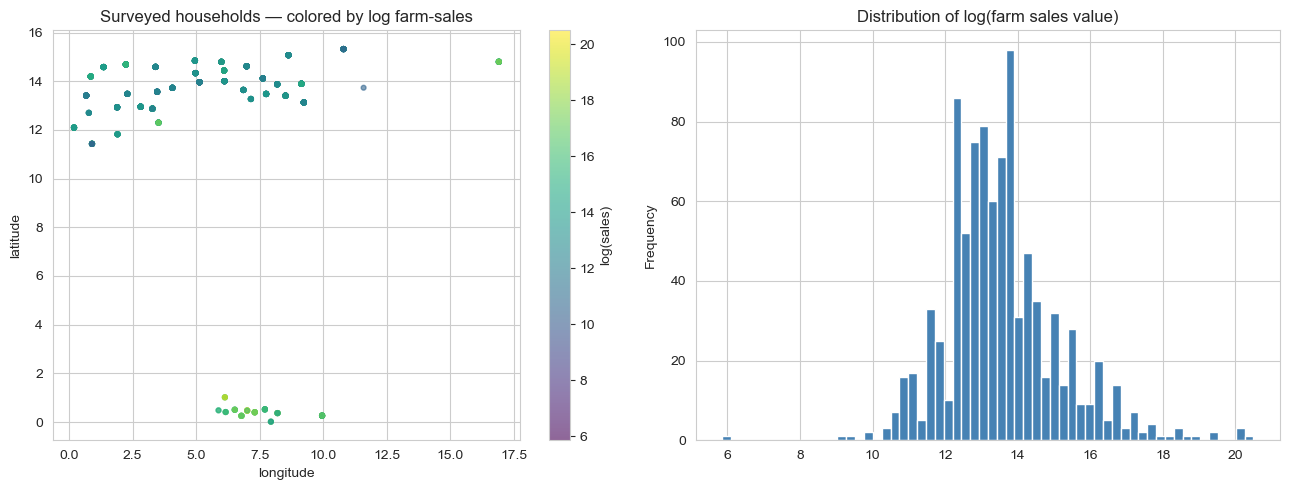

In [3]:
# Two-panel EDA: spatial scatter + log-sales distribution.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Spatial scatter: every household at its lat/lon, coloured by log-sales.
# Reveals spatial autocorrelation in sales — high-sales clusters that the GBM can split on.
sc = axes[0].scatter(df['lon'], df['lat'], c=df['log_sales'], cmap='viridis', s=12, alpha=0.6)
axes[0].set_title('Surveyed households — colored by log farm-sales')
axes[0].set_xlabel('longitude'); axes[0].set_ylabel('latitude')
plt.colorbar(sc, ax=axes[0], label='log(sales)')

# Log-sales distribution. Should be roughly bell-shaped after log1p.
df['log_sales'].plot(kind='hist', bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of log(farm sales value)')

plt.tight_layout(); plt.show()

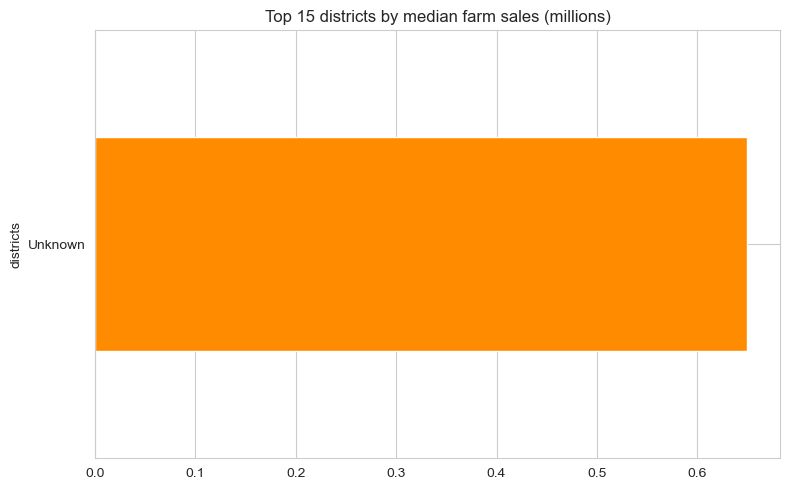

In [4]:
# Top 15 districts by median sales (in millions). Crude productivity ranking;
# the model will refine this with within-district covariate effects.
dist_med = df.groupby('districts')['farmsalev'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
(dist_med/1e6).plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()                                    # most-productive district on top
ax.set_title('Top 15 districts by median farm sales (millions)')
plt.tight_layout(); plt.show()

## 4. Modelling

Feature set: lat + lon (the spatial signal), plot/land area features, climate-shift exposure, district one-hot (collapsed to top-20 + 'Other' to avoid overfitting on tiny strata).

Two models on the same features: OLS for interpretable baseline, GBM for the lift from non-linear interactions.

In [5]:
# Collapse rare districts into 'Other' to avoid overfitting on strata with 1-2 households.
top_dist = df['districts'].value_counts().head(20).index
df['district_grp'] = np.where(df['districts'].isin(top_dist), df['districts'].astype(str), 'Other')

# Numeric feature columns. Some may be entirely NaN in the working subset; we'll handle that.
feat_cols = ['lat','lon','fplotarea1','landhhc1','landhhf1','landhhm1','longtermtempshifts1','longtermrainfallshifts1']

# Median-impute missing values per column. (Simpler than KNN imputation; survey data
# typically has missing-at-random patterns where median imputation is defensible.)
for c in feat_cols:
    df[c] = df[c].fillna(df[c].median())

# Drop columns that turned out entirely NaN (no median to impute from).
feat_cols = [c for c in feat_cols if df[c].notna().any()]
for c in feat_cols:
    df[c] = df[c].fillna(0)

# Build the design matrix: numeric features + one-hot district.
X = pd.concat([df[feat_cols],
               pd.get_dummies(df['district_grp'], prefix='dist', drop_first=True).astype(float)], axis=1)

# Defensive: replace any inf/-inf and remaining NaN with 0 so sklearn doesn't choke.
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['log_sales']

# Random 80/20 split.
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
print(f'features: {X.shape[1]}, train: {Xtr.shape}, test: {Xte.shape}')

features: 6, train: (744, 6), test: (187, 6)


In [6]:
# OLS baseline. statsmodels needs an explicit intercept column added.
import statsmodels.api as sm
ols = sm.OLS(ytr, sm.add_constant(Xtr)).fit()
ols_pred = ols.predict(sm.add_constant(Xte))
print(f'OLS R²={r2_score(yte, ols_pred):.3f}')

OLS R²=0.307


In [7]:
# GBM challenger. depth=4 because the lat × lon × district interaction structure
# benefits from deeper splits. 500 shallow-ish trees + low LR for strong regularisation.
gbm = GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
gbm_pred = gbm.predict(Xte)
print(f'GBM R²={r2_score(yte, gbm_pred):.3f}')

GBM R²=0.660


## 5. Validation

Same dual-scale metric pattern as the Lagos notebook:

- **R² (log)** + **MAE (log)** — on the scale where the model was fit.
- **MAPE (raw)** — back to the natural sales scale that microfinance / extension consumers actually use.

In [8]:
def metrics(y_log, yhat_log):
    """Compute metrics on both log-scale (fit) and raw-scale (consumer-facing)."""
    y, yhat = np.expm1(y_log), np.expm1(yhat_log)        # back-transform log -> raw
    return {'R² (log)': r2_score(y_log, yhat_log),
            'MAE (log)': mean_absolute_error(y_log, yhat_log),
            'MAPE (raw)': mean_absolute_percentage_error(y, yhat)}

scores = pd.DataFrame([{'model':'OLS', **metrics(yte, ols_pred)},
                       {'model':'GBM', **metrics(yte, gbm_pred)}])
scores.sort_values('R² (log)', ascending=False)

,model,R² (log),MAE (log),MAPE (raw)
1,GBM,0.660120,0.624046,0.743445
0,OLS,0.306636,0.947247,1.165255


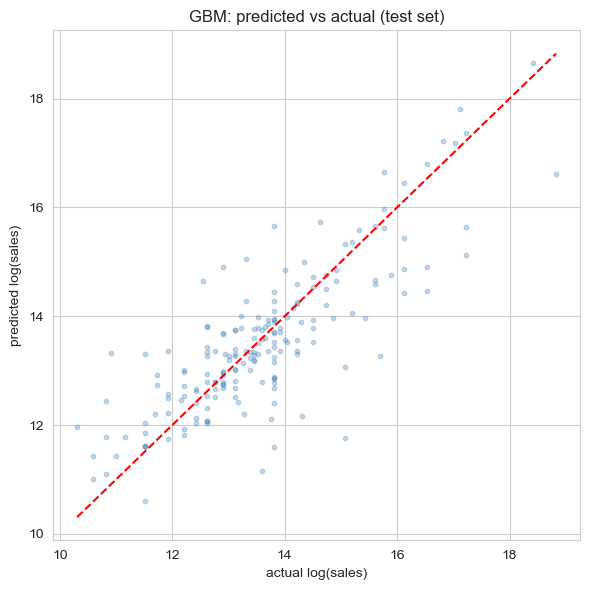

In [9]:
# Predicted-vs-actual scatter on log scale. The 45-degree red line is perfect prediction.
# Tighter scatter around the line = better calibration. Systematic deviation at the
# extremes (under-predicting big farms, over-predicting tiny farms) would suggest
# we should add monotonic constraints or a different loss function.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yte, gbm_pred, alpha=0.3, s=10, color='steelblue')
ax.plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'r--')
ax.set_xlabel('actual log(sales)'); ax.set_ylabel('predicted log(sales)')
ax.set_title('GBM: predicted vs actual (test set)')
plt.tight_layout(); plt.show()

## 6. Deployment

- **API:** `POST /farm-output-prediction` → expected log-sales + interval given farm attributes + coordinates.
- **Dashboard:** spatial heatmap of predicted vs realized sales — highlights underserved districts for input suppliers / microfinance.
- **Refresh:** re-run on the next survey wave; monitor calibration by district.

## 7. Business outcome

- Underwriting and field-targeting decisions backed by data, not vibes.
- Spatial heatmap surfaces underserved districts.
- Methodology applies to any geo-tagged agricultural survey or census.